# 3D Porous Media — Two Spheres (LBM Simulation)
## JAX D3Q19 Lattice Boltzmann Method with Zou-He Boundary Conditions

This notebook runs a 3D Lattice Boltzmann simulation of flow through a porous medium
consisting of two spheres, using the D3Q19 lattice model implemented in JAX.

**Features:**
- D3Q19 lattice with BGK collision operator
- Zou-He pressure boundary conditions at inlet/outlet
- Bounce-back for solid nodes
- Convergence check based on mean velocity
- Permeability calculation and comparison with Palabos reference

## 1. Imports

In [1]:
import jax
import jax.numpy as jnp
from jax import jit
import numpy as np
import time

print(f"JAX devices: {jax.devices()}")

JAX devices: [cuda(id=0), cuda(id=1), cuda(id=2)]


## 2. Simulation Parameters

These parameters are set to match the Palabos reference case.

In [2]:
# Raw grid dimensions (before padding)
NX_RAW, NY_RAW, NZ_RAW = 48, 64, 64

# Relaxation parameters
OMEGA = 1.0
TAU = 1.0
NU = 1.0 / 6.0

# Pressure drop
DELTA_P = 0.00005
RHO_IN = 1.0 
RHO_OUT = 1.0 - DELTA_P * 3.0

# Simulation control
MAX_STEPS = 300000
PRINT_EVERY = 500
CONV = 1e-4# Palabos uses 1e-4 on average energy

# Convergence window size (Palabos uses 1000 iterations)
CONV_WINDOW = 1000

# Lattice directions
Q = 19

print(f"Raw grid: {NX_RAW}x{NY_RAW}x{NZ_RAW}  omega={OMEGA}  nu={NU:.6f}  dP={DELTA_P}")

Raw grid: 48x64x64  omega=1.0  nu=0.166667  dP=5e-05


## 3. D3Q19 Lattice Definition

Define the lattice velocities, weights, and opposite directions for the D3Q19 model.

In [3]:
# D3Q19 lattice velocities
C = np.array([
    [0,0,0],                                          # rest
    [1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1],  # face neighbours
    [1,1,0],[-1,-1,0],[1,-1,0],[-1,1,0],              # edge neighbours (xy)
    [1,0,1],[-1,0,-1],[1,0,-1],[-1,0,1],              # edge neighbours (xz)
    [0,1,1],[0,-1,-1],[0,1,-1],[0,-1,1]               # edge neighbours (yz)
], dtype=np.int32)

# Weights
W = np.array([1./3.] + [1./18.]*6 + [1./36.]*12)

# Opposite direction indices
OPP = np.array([0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15, 18, 17])

# Reshaped arrays for broadcasting (4D: Q x NX x NY x NZ)
cx4 = jnp.array(C[:,0]).reshape(Q,1,1,1)
cy4 = jnp.array(C[:,1]).reshape(Q,1,1,1)
cz4 = jnp.array(C[:,2]).reshape(Q,1,1,1)
w4  = jnp.array(W).reshape(Q,1,1,1)

# Reshaped arrays for broadcasting (3D: Q x NY x NZ) — used in BC
cx2 = jnp.array(C[:,0]).reshape(Q,1,1)
cy2 = jnp.array(C[:,1]).reshape(Q,1,1)
cz2 = jnp.array(C[:,2]).reshape(Q,1,1)
w2  = jnp.array(W).reshape(Q,1,1)
opp = jnp.array(OPP)

# Direction groups for Zou-He BC
POS_X  = jnp.array([1, 7, 9, 11, 13])   # positive x-velocity directions
NEG_X  = jnp.array([2, 8, 10, 12, 14])  # negative x-velocity directions
ZERO_X = jnp.array([0, 3, 4, 5, 6, 15, 16, 17, 18])  # zero x-velocity

print("D3Q19 lattice initialised.")

D3Q19 lattice initialised.


## 4. Geometry Loading & Padding

Read the `twoSpheres.dat` geometry file. Node types:
- **0** = fluid
- **1** = bounce-back (solid)
- **2** = no-dynamics (exterior)

**Padding strategy (supervisor's approach for x-direction flow):**
1. **One layer of solid (BB=1)** on both sides of y and z (cross-flow walls).
2. **One layer of void/fluid (0)** at the outlet end of x (flow direction) for better convergence.

Padding is excluded when computing permeability and other physical quantities.

In [4]:
print("Reading geometry...")
geo_raw = np.loadtxt("twoSpheres.dat", dtype=int).reshape(NX_RAW, NY_RAW, NZ_RAW)
geo_raw[-1, :, :] = 0  # Palabos reads only nx-1 slices

print(f"  Raw shape: {geo_raw.shape}")
print(f"  Raw — Fluid={int(np.sum(geo_raw==0))}  BB={int(np.sum(geo_raw==1))}  ND={int(np.sum(geo_raw==2))}")

# ── Padding ──
# Step 1: Pad 1 layer of solid (BB=1) on both sides of y and z (cross-flow walls)
# geo_yz = np.pad(geo_raw,
#                 pad_width=((0, 0), (1, 1), (1, 1)),
#                 mode='constant', constant_values=1)

# Step 2: Add 1 void (fluid=0) layer at the outlet end of x (flow direction)
#void_layer = np.zeros((1, geo_yz.shape[1], geo_yz.shape[2]), dtype=int)
#geo = np.concatenate([geo_yz], axis=0)
geo=geo_raw

# Update grid dimensions after padding
NX, NY, NZ = geo.shape
print(f"\n  After padding: {NX}x{NY}x{NZ}")
print(f"  y-direction: +1 solid each side  ({NY_RAW} -> {NY})")
print(f"  z-direction: +1 solid each side  ({NZ_RAW} -> {NZ})")
print(f"  x-direction: +1 void at outlet   ({NX_RAW} -> {NX})")
print(f"  Padded — Fluid={int(np.sum(geo==0))}  BB={int(np.sum(geo==1))}  ND={int(np.sum(geo==2))}")

# Check boundary fluid exposure
print(f"\n  Fluid on y-boundaries: y=0: {int(np.sum(geo[:,0,:]==0))}, y={NY-1}: {int(np.sum(geo[:,-1,:]==0))}")
print(f"  Fluid on z-boundaries: z=0: {int(np.sum(geo[:,:,0]==0))}, z={NZ-1}: {int(np.sum(geo[:,:,-1]==0))}")

# Boolean masks (with leading singleton dim for broadcasting with f)
is_fluid = jnp.array(geo == 0)[None]
is_bb    = jnp.array(geo == 1)[None]
is_nd    = jnp.array(geo == 2)[None]

# Inlet / outlet masks — interior fluid cells on x-faces
inm  = np.zeros((NY, NZ), bool)
outm = np.zeros((NY, NZ), bool)
inm[1:NY-1, 1:NZ-1]  = (geo[0,  1:NY-1, 1:NZ-1] == 0)
outm[1:NY-1, 1:NZ-1] = (geo[-1, 1:NY-1, 1:NZ-1] == 0)
inlet_mask  = jnp.array(inm)[None]
outlet_mask = jnp.array(outm)[None]

print(f"  Inlet fluid nodes  = {int(np.sum(inm))}")
print(f"  Outlet fluid nodes = {int(np.sum(outm))}")

Reading geometry...
  Raw shape: (48, 64, 64)
  Raw — Fluid=109835  BB=13632  ND=73141

  After padding: 48x64x64
  y-direction: +1 solid each side  (64 -> 64)
  z-direction: +1 solid each side  (64 -> 64)
  x-direction: +1 void at outlet   (48 -> 48)
  Padded — Fluid=109835  BB=13632  ND=73141

  Fluid on y-boundaries: y=0: 64, y=63: 64
  Fluid on z-boundaries: z=0: 64, z=63: 64
  Inlet fluid nodes  = 2821
  Outlet fluid nodes = 3844


### 4a. Before & After Padding

Side-by-side comparison of the geometry before and after padding.
- **White** = fluid (0), **Black** = bounce-back / solid (1), **Grey** = no-dynamics (2)
- Red dashed lines = y solid padding, green dashed lines = z solid padding, blue dashed line = x outlet void layer.

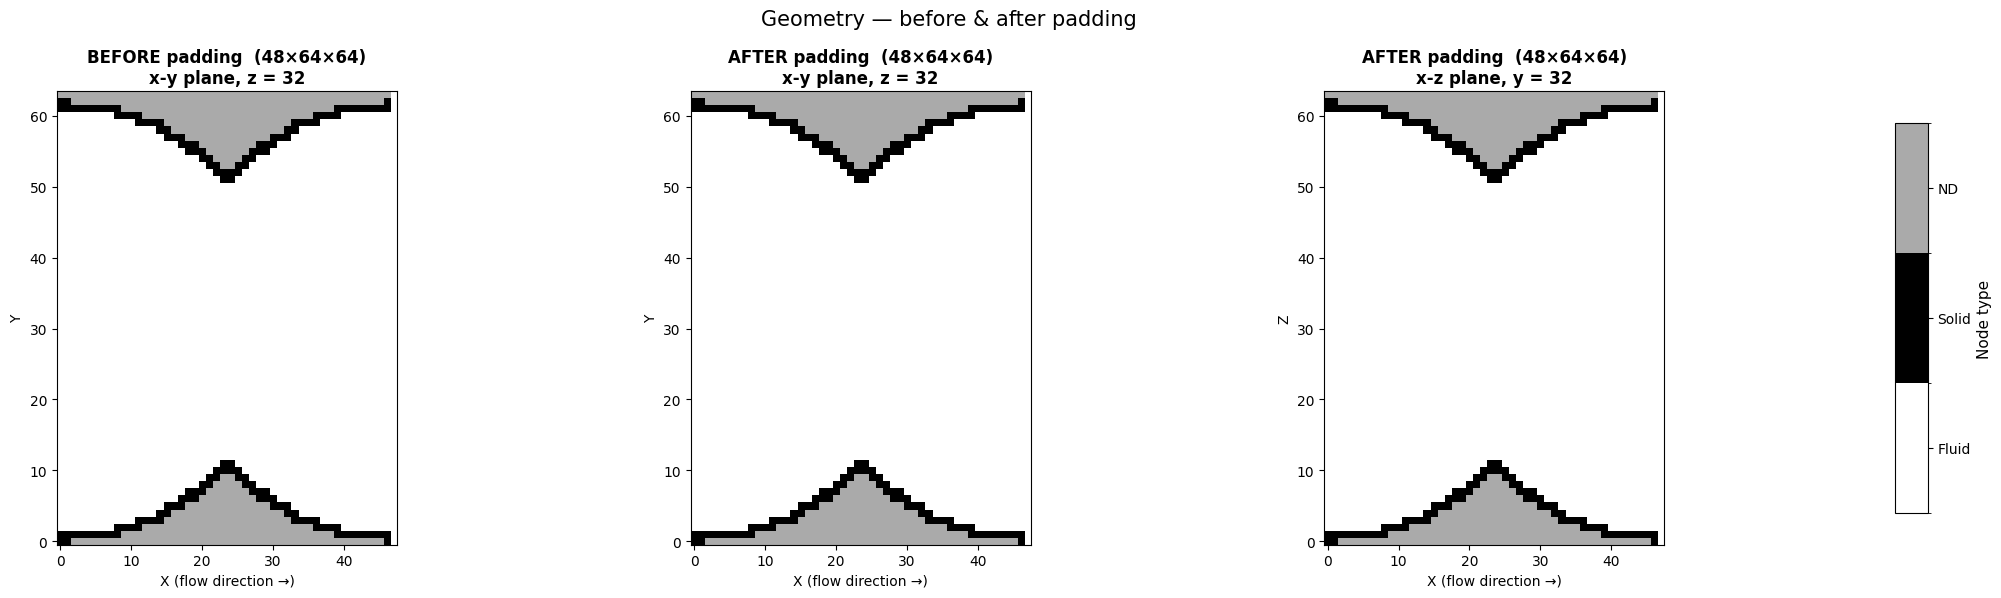

Original domain : 48 x 64 x 64
Padded domain   : 48 x 64 x 64
  y: +1 solid each side   (64 -> 64)
  z: +1 solid each side   (64 -> 64)
  x: +1 void at outlet    (48 -> 48)


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Custom colourmap: fluid=white, solid=black, ND=grey
cmap_geo = mcolors.ListedColormap(['white', 'black', '#aaaaaa'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm_geo = mcolors.BoundaryNorm(bounds, cmap_geo.N)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Left: BEFORE padding (raw geometry, x-y plane at mid-z) ──
zc_raw = NZ_RAW // 2
ax = axes[0]
im = ax.imshow(geo_raw[:, :, zc_raw].T, origin='lower',
               cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'BEFORE padding  ({NX_RAW}×{NY_RAW}×{NZ_RAW})\nx-y plane, z = {zc_raw}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Y')

# ── Centre: AFTER padding (x-y plane at mid-z — shows y padding + outlet void) ──
zc = NZ // 2
ax = axes[1]
ax.imshow(geo[:, :, zc].T, origin='lower',
          cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'AFTER padding  ({NX}×{NY}×{NZ})\nx-y plane, z = {zc}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Y')
# y-direction solid padding
# ax.axhline(0.5, color='red', ls='--', lw=1.5, label='y solid pad')
# ax.axhline(NY - 1.5, color='red', ls='--', lw=1.5)
# # x-direction outlet void layer
# ax.axvline(NX - 1.5, color='blue', ls='--', lw=1.5, label='x outlet void')
# ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# ── Right: AFTER padding (x-z plane at mid-y — shows z padding + outlet void) ──
yc = NY // 2
ax = axes[2]
ax.imshow(geo[:, yc, :].T, origin='lower',
          cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'AFTER padding  ({NX}×{NY}×{NZ})\nx-z plane, y = {yc}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Z')
# z-direction solid padding
# ax.axhline(0.5, color='green', ls='--', lw=1.5, label='z solid pad')
# ax.axhline(NZ - 1.5, color='green', ls='--', lw=1.5)
# # x-direction outlet void layer
# ax.axvline(NX - 1.5, color='blue', ls='--', lw=1.5, label='x outlet void')
# ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# Colorbar: manually placed far right
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.65])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0, 1, 2])
cbar.set_label('Node type', fontsize=11)
cbar.ax.set_yticklabels(['Fluid', 'Solid', 'ND'])

fig.suptitle('Geometry — before & after padding', fontsize=15, y=0.99)
plt.show()

print(f"Original domain : {NX_RAW} x {NY_RAW} x {NZ_RAW}")
print(f"Padded domain   : {NX} x {NY} x {NZ}")
print(f"  y: +1 solid each side   ({NY_RAW} -> {NY})")
print(f"  z: +1 solid each side   ({NZ_RAW} -> {NZ})")
print(f"  x: +1 void at outlet    ({NX_RAW} -> {NX})")

## 5. Core LBM Functions

Equilibrium distribution, macroscopic quantities, streaming, and boundary conditions.

In [6]:
def eq3d(rho, ux, uy, uz):
    """Equilibrium distribution (full 3D field)."""
    usq = ux*ux + uy*uy + uz*uz
    cu  = cx4*ux[None] + cy4*uy[None] + cz4*uz[None]
    return w4 * rho[None] * (1 + 3*cu + 4.5*cu*cu - 1.5*usq[None])

def eq2d(rho, ux, uy, uz):
    """Equilibrium distribution (2D slice, for BCs)."""
    usq = ux*ux + uy*uy + uz*uz
    cu  = cx2*ux[None] + cy2*uy[None] + cz2*uz[None]
    return w2 * rho[None] * (1 + 3*cu + 4.5*cu*cu - 1.5*usq[None])

def macro(f):
    """Compute macroscopic quantities from distribution."""
    rho = jnp.sum(f, 0)
    ux  = jnp.sum(f * cx4, 0) / rho
    uy  = jnp.sum(f * cy4, 0) / rho
    uz  = jnp.sum(f * cz4, 0) / rho
    return rho, ux, uy, uz

def stream(f):
    """Streaming step: shift each population along its lattice velocity."""
    out = jnp.zeros_like(f)
    for q in range(Q):
        s = jnp.roll(f[q], C[q,0], 0)
        s = jnp.roll(s,    C[q,1], 1)
        s = jnp.roll(s,    C[q,2], 2)
        out = out.at[q].set(s)
    return out

print("Core functions defined.")

Core functions defined.


## 6. Zou-He Pressure Boundary Conditions

Pressure-driven flow: set density (pressure) at inlet and outlet faces.

In [7]:
def zou_he_inlet(f):
    """Apply Zou-He pressure BC at inlet (x = 0)."""
    s = f[:, 0, :, :]
    rho_in = RHO_IN * jnp.ones((NY, NZ))
    ux_in  = 1.0 - (jnp.sum(s[ZERO_X], 0) + 2*jnp.sum(s[NEG_X], 0)) / rho_in
    feq    = eq2d(rho_in, ux_in, jnp.zeros((NY,NZ)), jnp.zeros((NY,NZ)))
    return f.at[:, 0, :, :].set(jnp.where(inlet_mask, feq, s))

def zou_he_outlet(f):
    """Apply Zou-He pressure BC at outlet (x = NX-1)."""
    s = f[:, -1, :, :]
    rho_out = RHO_OUT * jnp.ones((NY, NZ))
    ux_out  = -1.0 + (jnp.sum(s[ZERO_X], 0) + 2*jnp.sum(s[POS_X], 0)) / rho_out
    feq     = eq2d(rho_out, ux_out, jnp.zeros((NY,NZ)), jnp.zeros((NY,NZ)))
    return f.at[:, -1, :, :].set(jnp.where(outlet_mask, feq, s))

print("Boundary condition functions defined.")

Boundary condition functions defined.


## 7. LBM Time Step

One complete LBM step: collision → streaming → boundary conditions.

In [8]:
@jit
def one_step(f, is_fluid, is_bb, is_nd):
    """Single LBM time step."""
    # Collision: fluid → BGK, bounce-back → swap, no-dynamics → skip
    _, ux, uy, uz = macro(f)
    rho = jnp.sum(f, 0)
    feq = eq3d(rho, ux, uy, uz)
    f_coll = jnp.where(is_bb, f[opp],
             jnp.where(is_nd, f,
                        f - (f - feq) / TAU))
    # Streaming
    f_str = stream(f_coll)
    # Zou-He pressure BC
    f_str = zou_he_inlet(f_str)
    f_str = zou_he_outlet(f_str)
    return f_str

print("one_step function defined.")

one_step function defined.


## 8. Initialisation

Start with a linear pressure gradient from inlet to outlet.

In [9]:
print("Initialising distribution functions...")
x = np.arange(NX, dtype=np.float64)
rho0 = jnp.array(
    np.broadcast_to(
        (1.0 - DELTA_P * 3 / (NX-1) * x)[:, None, None],
        (NX, NY, NZ)
    ).copy()
)
z = jnp.zeros((NX, NY, NZ))
f = eq3d(rho0, z, z, z)

# JIT warm-up
print("JIT compiling (first call)...")
t0 = time.time()
f = one_step(f, is_fluid, is_bb, is_nd)
f.block_until_ready()
print(f"JIT compilation took {time.time()-t0:.1f} s")

Initialising distribution functions...
JIT compiling (first call)...
JIT compilation took 0.5 s


## 9. Main Simulation Loop

**Convergence criterion (Palabos-style):**
Track the average kinetic energy ½ρ|u|² over the entire lattice.
A sliding window average (window = 1000 iterations) is compared every
500 steps; the simulation stops when the relative change drops below 1e-4.

This mirrors Palabos's `util::ValueTracer` with `getStoredAverageEnergy`.

In [10]:
def compute_avg_energy(f):
    """Average kinetic energy = 0.5 * <rho * |u|^2> over all cells.
    This matches Palabos getStoredAverageEnergy()."""
    rho = jnp.sum(f, 0)
    ux  = jnp.sum(f * cx4, 0) / rho
    uy  = jnp.sum(f * cy4, 0) / rho
    uz  = jnp.sum(f * cz4, 0) / rho
    energy = 0.5 * rho * (ux**2 + uy**2 + uz**2)
    return float(jnp.mean(energy))
    
print(f"Running simulation (max {MAX_STEPS} steps)...")
print(f"Convergence: avg energy window={CONV_WINDOW}, threshold={CONV}")
t0 = time.time()

# Sliding window for energy values (sampled every PRINT_EVERY steps)
energy_history = []
prev_window_avg = None

for step in range(1, MAX_STEPS + 1):
    f = one_step(f, is_fluid, is_bb, is_nd)

    if step % PRINT_EVERY == 0:
        f.block_until_ready()
        avg_E = compute_avg_energy(f)
        energy_history.append(avg_E)

        # Window average: use last N samples where N covers ~CONV_WINDOW iterations
        window_samples = max(1, CONV_WINDOW // PRINT_EVERY)  # 1000/500 = 2
        if len(energy_history) >= window_samples:
            window_avg = np.mean(energy_history[-window_samples:])
        else:
            window_avg = np.mean(energy_history)

        # Relative change between successive window averages
        if prev_window_avg is not None and window_avg != 0:
            rel = abs(window_avg - prev_window_avg) / abs(window_avg)
        else:
            rel = 1.0

        print(f"  step {step:5d}  <E> = {avg_E:.6e}  window_avg = {window_avg:.6e}  rel = {rel:.2e}")

        if rel < CONV and step > 1000:
            print("  >>> CONVERGED (Palabos-style energy criterion)")
            break

        prev_window_avg = window_avg

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f} s  ({NX*NY*NZ*step/elapsed/1e6:.0f} MLUPS)")

Running simulation (max 300000 steps)...
Convergence: avg energy window=1000, threshold=0.0001
  step   500  <E> = 1.803527e-08  window_avg = 1.803527e-08  rel = 1.00e+00
  step  1000  <E> = 3.413802e-08  window_avg = 2.608664e-08  rel = 3.09e-01
  step  1500  <E> = 4.180258e-08  window_avg = 3.797030e-08  rel = 3.13e-01
  step  2000  <E> = 4.500718e-08  window_avg = 4.340488e-08  rel = 1.25e-01
  step  2500  <E> = 4.629048e-08  window_avg = 4.564883e-08  rel = 4.92e-02
  step  3000  <E> = 4.679578e-08  window_avg = 4.654313e-08  rel = 1.92e-02
  step  3500  <E> = 4.698955e-08  window_avg = 4.689266e-08  rel = 7.45e-03
  step  4000  <E> = 4.706679e-08  window_avg = 4.702817e-08  rel = 2.88e-03
  step  4500  <E> = 4.710001e-08  window_avg = 4.708340e-08  rel = 1.17e-03
  step  5000  <E> = 4.711265e-08  window_avg = 4.710633e-08  rel = 4.87e-04
  step  5500  <E> = 4.711614e-08  window_avg = 4.711439e-08  rel = 1.71e-04
  step  6000  <E> = 4.711704e-08  window_avg = 4.711659e-08  rel = 4.

## 10. Results & Permeability

Compute macroscopic fields, derive permeability via Darcy's law, and visualise the full flow field.

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# ── Macroscopic fields (full padded domain) ──
rho, ux, uy, uz = macro(f)

# Convert to numpy for plotting
ux_np  = np.array(ux)
uy_np  = np.array(uy)
uz_np  = np.array(uz)
rho_np = np.array(rho)
umag   = np.sqrt(ux_np**2 + uy_np**2 + uz_np**2)

# Masks (full padded domain — used for plotting)
solid       = (geo != 0)
fluid_mask  = (geo == 0)
umag_masked = np.where(solid, np.nan, umag)
rho_masked  = np.where(solid, np.nan, rho_np)

# ── Key quantities on the ORIGINAL (unpadded) interior only ──
# Padding: y ±1 solid, z ±1 solid, x +1 void at outlet
# Original interior: x in [0:NX_RAW], y in [1:-1], z in [1:-1]
ux_interior  = ux_np[:NX_RAW -1, 1:-1, 1:-1]
geo_interior = geo[:NX_RAW-1, 1:-1, 1:-1]   # should match geo_raw

# ── FIX: zero out solid nodes before summing (Palabos sums momentum only
# from fluid nodes but divides by ALL nodes → Darcy/superficial velocity) ──
fluid_mask_interior = (geo_interior == 0)          # True only at fluid nodes
ux_zeroed    = np.where(fluid_mask_interior, ux_interior, 0.0)
avg_velocity = float(np.sum(ux_zeroed) / ((NX_RAW-1) * NY_RAW * NZ_RAW))
grad_P       = DELTA_P / (NX_RAW-1)
K            = NU * avg_velocity / grad_P

palabos_ref  = 27.7554 # actual Palabos result for this chalk geometry
rel_err      = abs(K - palabos_ref) / palabos_ref * 100

print("=" * 58)
print("  Properties computed on ORIGINAL interior only")
print(f"  (stripping padding: {NX}x{NY}x{NZ} -> {NX_RAW}x{NY_RAW}x{NZ_RAW})")
print("=" * 58)
print(f"  Average velocity     = {avg_velocity:.6e}")
print(f"  Lattice viscosity nu = {NU:g}")
print(f"  Grad P               = {grad_P:.6e}")
print(f"  Permeability         = {K:.6g}")
print(f"  Palabos ref          = {palabos_ref}")
print(f"  Relative error       = {rel_err:.2f}%")
print("=" * 58)
print(f"  |u| range in fluid   : [{np.nanmin(umag_masked):.2e}, {np.nanmax(umag_masked):.2e}]")
print(f"  rho range in fluid   : [{np.nanmin(rho_masked):.6f}, {np.nanmax(rho_masked):.6f}]")

  Properties computed on ORIGINAL interior only
  (stripping padding: 48x64x64 -> 48x64x64)
  Average velocity     = 1.772355e-04
  Lattice viscosity nu = 0.166667
  Grad P               = 1.063830e-06
  Permeability         = 27.7669
  Palabos ref          = 27.7554
  Relative error       = 0.04%
  |u| range in fluid   : [0.00e+00, 9.84e-04]
  rho range in fluid   : [0.999824, 1.000024]


### 10a. Summary Dashboard

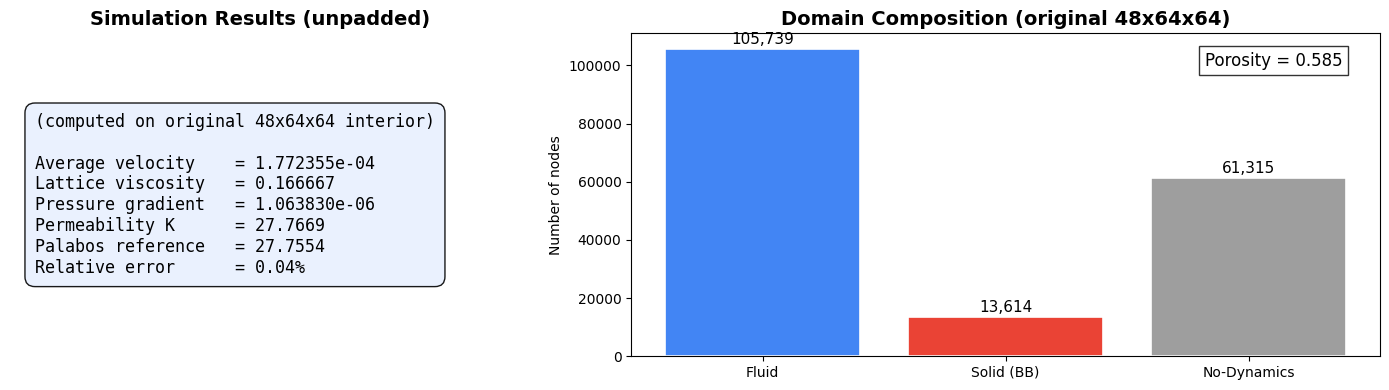

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={'width_ratios': [1, 1.5]})

# Left: text summary panel
ax_txt = axes[0]
ax_txt.axis('off')
summary = (
    f"(computed on original {NX_RAW}x{NY_RAW}x{NZ_RAW} interior)\n\n"
    f"Average velocity    = {avg_velocity:.6e}\n"
    f"Lattice viscosity   = {NU:g}\n"
    f"Pressure gradient   = {grad_P:.6e}\n"
    f"Permeability K      = {K:.6g}\n"
    f"Palabos reference   = {palabos_ref}\n"
    f"Relative error      = {rel_err:.2f}%"
)
ax_txt.text(0.05, 0.5, summary, transform=ax_txt.transAxes,
            fontsize=12, fontfamily='monospace', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#e8f0fe', alpha=0.9))
ax_txt.set_title('Simulation Results (unpadded)', fontsize=14, fontweight='bold')

# Right: porosity & node breakdown (original domain)
labels  = ['Fluid', 'Solid (BB)', 'No-Dynamics']
counts  = [int(np.sum(geo_interior==0)), int(np.sum(geo_interior==1)), int(np.sum(geo_interior==2))]
colors  = ['#4285f4', '#ea4335', '#9e9e9e']
bars = axes[1].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylabel('Number of nodes')
axes[1].set_title(f'Domain Composition (original {NX_RAW}x{NY_RAW}x{NZ_RAW})',
                  fontsize=14, fontweight='bold')
for b, c in zip(bars, counts):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+500,
                 f'{c:,}', ha='center', va='bottom', fontsize=11)
porosity = counts[0] / sum(counts)
axes[1].text(0.95, 0.90, f'Porosity = {porosity:.3f}',
             transform=axes[1].transAxes, ha='right', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### 10b. Velocity Magnitude — Mid-plane Slices

Three orthogonal cuts through the domain centre. Solid regions appear as NaN (dark).

/tmp/ipykernel_4051642/1085356826.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


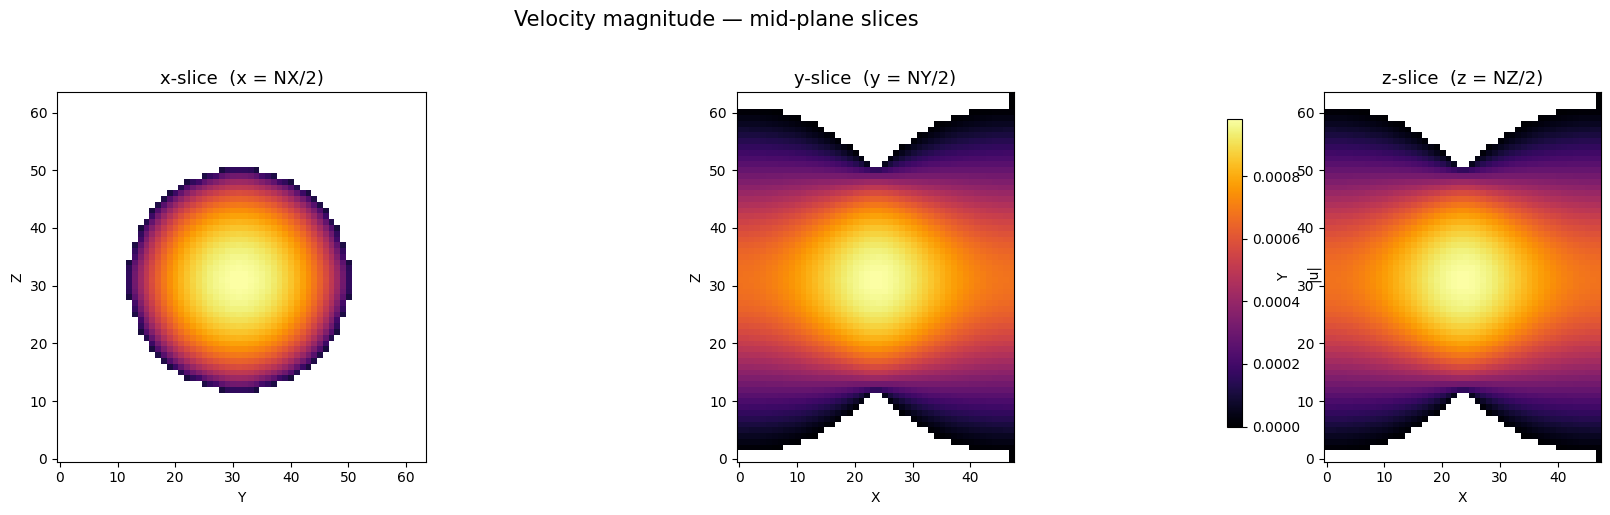

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

slices = [
    ("x-slice  (x = NX/2)",  umag_masked[NX//2, :, :],  "Y", "Z"),
    ("y-slice  (y = NY/2)",  umag_masked[:, NY//2, :],   "X", "Z"),
    ("z-slice  (z = NZ/2)",  umag_masked[:, :, NZ//2],   "X", "Y"),
]

vmax = np.nanmax(umag_masked)
for ax, (title, data, xl, yl) in zip(axes, slices):
    im = ax.imshow(data.T, origin='lower', cmap='inferno',
                   vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xl); ax.set_ylabel(yl)

fig.colorbar(im, ax=axes, label='|u|', shrink=0.8)
fig.suptitle('Velocity magnitude — mid-plane slices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 10c. Velocity Vectors — Mid-z Plane

Quiver plot of the in-plane velocity (u_x, u_y) coloured by speed,
with solid regions filled.

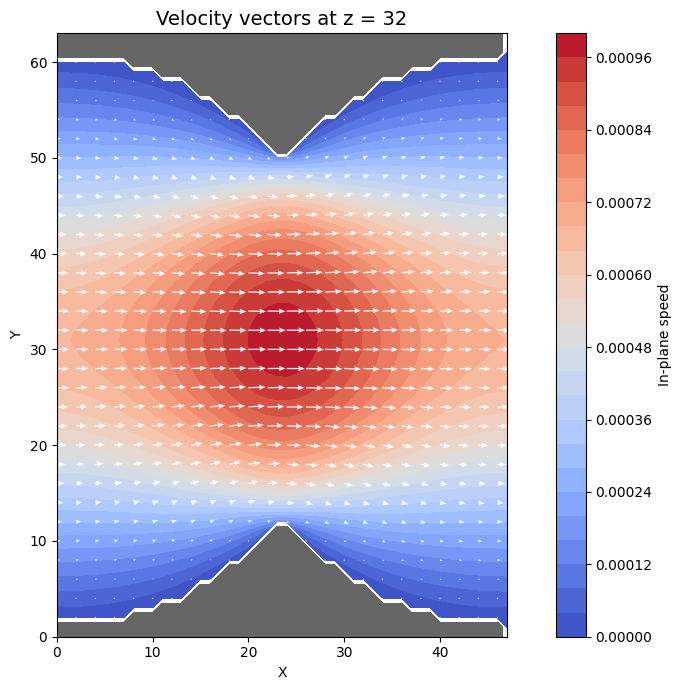

In [14]:
zc = NZ // 2
skip = 2  # subsample for clarity

yy, xx = np.meshgrid(np.arange(NY), np.arange(NX))

ux_sl = np.where(solid[:, :, zc], np.nan, ux_np[:, :, zc])
uy_sl = np.where(solid[:, :, zc], np.nan, uy_np[:, :, zc])
sp_sl = np.sqrt(ux_sl**2 + uy_sl**2)

fig, ax = plt.subplots(figsize=(10, 7))

cf = ax.contourf(xx, yy, sp_sl, levels=30, cmap='coolwarm')
plt.colorbar(cf, ax=ax, label='In-plane speed')

ax.contourf(xx, yy, solid[:, :, zc].astype(float),
            levels=[0.5, 1.5], colors='0.25', alpha=0.8)

ax.quiver(xx[::skip, ::skip], yy[::skip, ::skip],
          ux_sl[::skip, ::skip], uy_sl[::skip, ::skip],
          color='white', scale=None, width=0.003, headwidth=4, alpha=0.9)

ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Velocity vectors at z = {zc}', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 10d. Streamwise Velocity Profile

Cross-section-averaged u_x along the flow direction, showing acceleration
through the pore constriction.

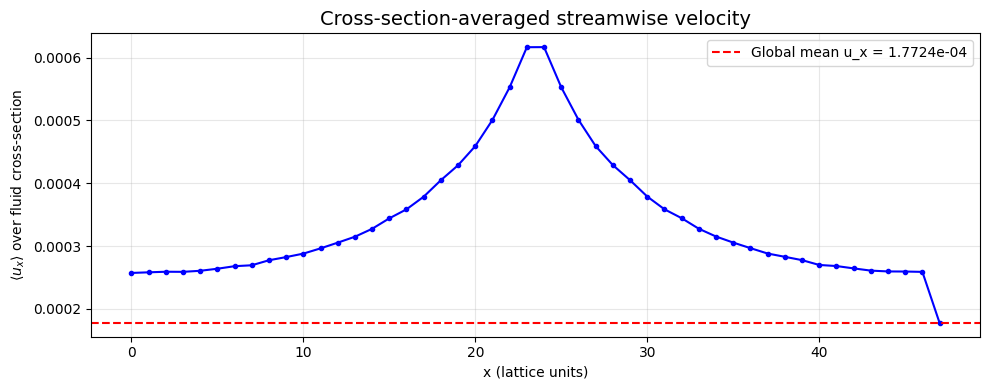

In [15]:
ux_profile = np.array([
    ux_np[i, fluid_mask[i]].mean() if fluid_mask[i].any() else 0.0
    for i in range(NX)
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(NX), ux_profile, 'b-o', markersize=3, linewidth=1.5)
ax.axhline(avg_velocity, color='r', ls='--',
           label=f'Global mean u_x = {avg_velocity:.4e}')
ax.set_xlabel('x (lattice units)')
ax.set_ylabel(r'$\langle u_x \rangle$ over fluid cross-section')
ax.set_title('Cross-section-averaged streamwise velocity', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10e. Pressure (Density) Field — Mid-z Plane

Density ρ is proportional to pressure (p = ρ c_s²). White contours mark the solid boundaries.

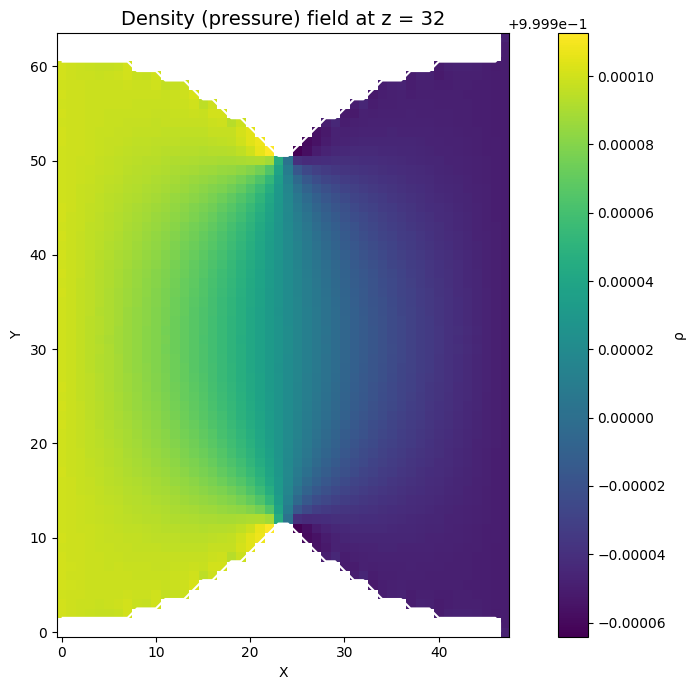

In [16]:
zc = NZ // 2

fig, ax = plt.subplots(figsize=(10, 7))
rho_sl = np.where(solid[:, :, zc], np.nan, rho_np[:, :, zc])

im = ax.imshow(rho_sl.T, origin='lower', cmap='viridis', aspect='equal')
ax.contour(solid[:, :, zc].T.astype(float), levels=[0.5],
           colors='white', linewidths=1.5)
plt.colorbar(im, ax=ax, label='ρ')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Density (pressure) field at z = {zc}', fontsize=14)
plt.tight_layout()
plt.show()

### 10f. 3D Geometry Visualisation

Solid voxels (bounce-back nodes) rendered in 3D, coloured by distance
from the domain centre to highlight the two spheres.

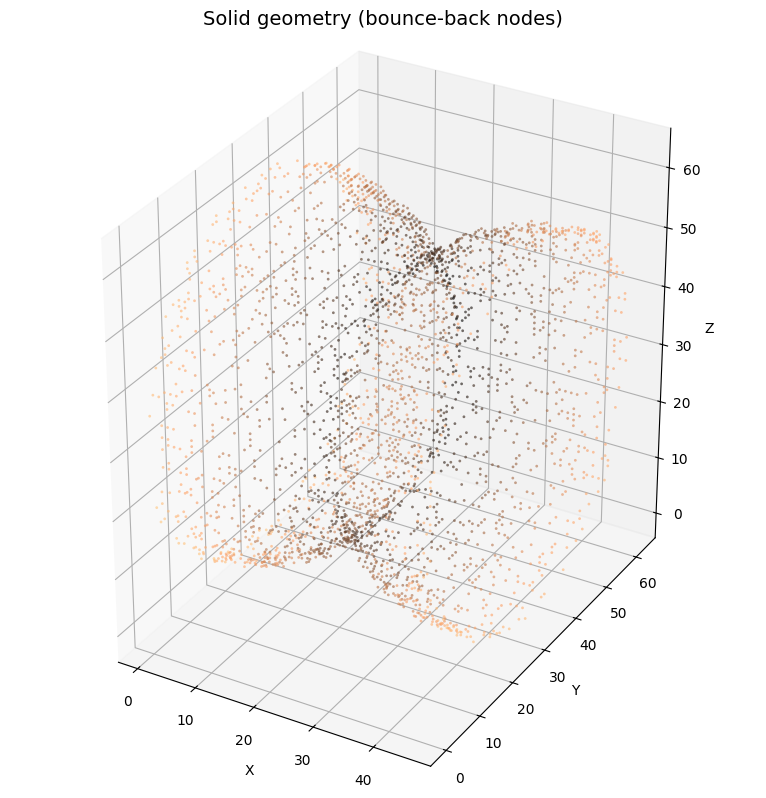

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

bb = (geo == 1)
xs, ys, zs = np.where(bb)

if len(xs) > 3000:
    idx = np.random.choice(len(xs), 3000, replace=False)
    xs, ys, zs = xs[idx], ys[idx], zs[idx]

cx_c, cy_c, cz_c = NX/2, NY/2, NZ/2
dist = np.sqrt((xs - cx_c)**2 + (ys - cy_c)**2 + (zs - cz_c)**2)
dist_norm = (dist - dist.min()) / (dist.max() - dist.min() + 1e-10)

ax.scatter(xs, ys, zs, c=dist_norm, cmap='copper', s=4, alpha=0.6, edgecolors='none')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Solid geometry (bounce-back nodes)', fontsize=14)
ax.set_box_aspect([NX, NY, NZ])
plt.tight_layout()
plt.show()

### 10g. Streamlines + Velocity Magnitude

In-plane streamlines overlaid on velocity magnitude at the mid-z plane,
with solid boundaries outlined in white.

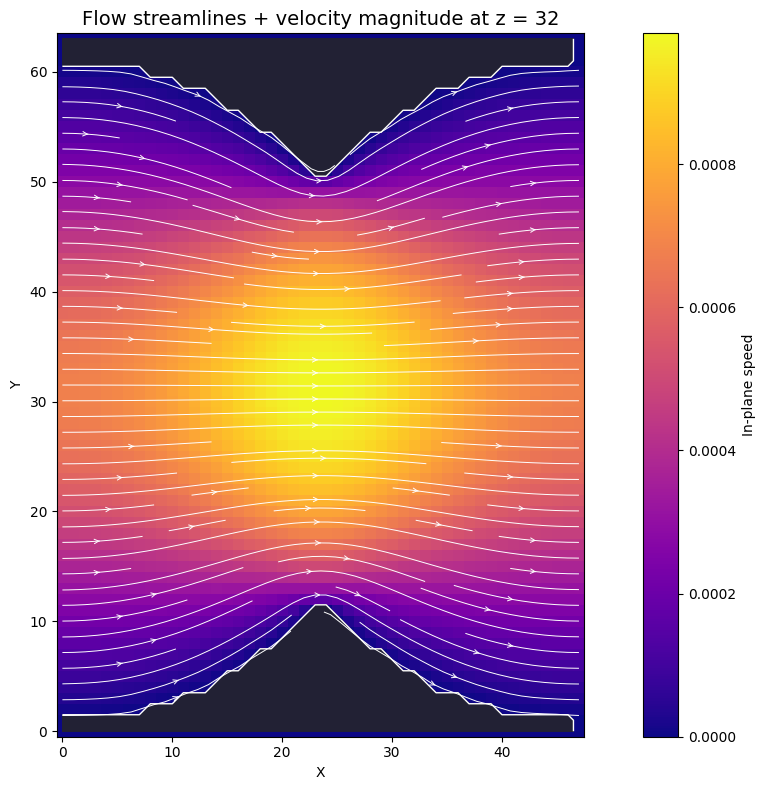

In [18]:
zc = NZ // 2

fig, ax = plt.subplots(figsize=(12, 8))

sp   = np.sqrt(ux_np[:, :, zc]**2 + uy_np[:, :, zc]**2)
sp_m = np.where(solid[:, :, zc], 0, sp)

im = ax.imshow(sp_m.T, origin='lower', cmap='plasma', aspect='equal')
plt.colorbar(im, ax=ax, label='In-plane speed')

ax.contourf(np.arange(NX), np.arange(NY), solid[:, :, zc].T.astype(float),
            levels=[0.5, 1.5], colors='0.15', alpha=0.85)
ax.contour(np.arange(NX), np.arange(NY), solid[:, :, zc].T.astype(float),
           levels=[0.5], colors='white', linewidths=1)

ux_stream = np.where(solid[:, :, zc], 0, ux_np[:, :, zc])
uy_stream = np.where(solid[:, :, zc], 0, uy_np[:, :, zc])

try:
    ax.streamplot(np.arange(NX), np.arange(NY),
                  ux_stream.T, uy_stream.T,
                  color='white', linewidth=0.7, density=1.5,
                  arrowsize=0.8, arrowstyle='->')
except:
    pass  # streamplot can fail for very small velocities

ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Flow streamlines + velocity magnitude at z = {zc}', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Save Results

In [19]:
np.savez("lbm_twospheres_results.npz",
    geometry=geo,
    ux=ux_np, uy=uy_np, uz=uz_np, rho=rho_np,
    permeability=K, mean_ux=avg_velocity,
    NX=NX, NY=NY, NZ=NZ, nu=NU, deltaP=DELTA_P
)
print("Saved → lbm_twospheres_results.npz")
print("\nAll results and visualisations complete.")

Saved → lbm_twospheres_results.npz

All results and visualisations complete.
